## **Exercise 07 : Heatmap**

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable

pd.options.display.max_rows = 15
connection = sqlite3.connect('../data/checking-logs.sqlite')
commits = pd.read_sql('select uid, timestamp as commits from checker where uid like "%user_%"', connection)
commits[['date', 'hour']] = commits['commits'].apply(lambda x: pd.Series([i for i in x.split()]))
commits['date'] = pd.to_datetime(commits['date']).dt.dayofweek
commits = commits.groupby(['uid', 'date'])['commits'].count()
commits = commits.to_frame().unstack()
commits.columns = commits.columns.droplevel(0)
commits.fillna(0, inplace=True)
commits1 = commits.T
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
commits1 = commits1[commits1.sum().sort_values(ascending=False).index]
users = list(commits1.columns)
commits1

uid,user_4,user_14,user_2,user_25,user_19,user_26,user_20,user_31,user_10,user_3,...,user_17,user_16,user_27,user_15,user_6,user_11,user_7,user_22,user_23,user_0
date,,,,,,,,,,,,,,,,,,,,,
0,35.0,50.0,24.0,14.0,7.0,0.0,23.0,5.0,0.0,46.0,...,8.0,10.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,3.0
1,86.0,87.0,131.0,44.0,9.0,1.0,0.0,0.0,16.0,11.0,...,4.0,5.0,0.0,0.0,0.0,0.0,5.0,3.0,0.0,0.0
2,33.0,0.0,32.0,15.0,0.0,34.0,8.0,0.0,37.0,0.0,...,1.0,0.0,0.0,0.0,4.0,0.0,3.0,0.0,0.0,0.0
3,108.0,17.0,4.0,40.0,78.0,51.0,96.0,7.0,77.0,7.0,...,17.0,14.0,15.0,5.0,2.0,0.0,0.0,2.0,6.0,0.0
4,61.0,0.0,0.0,10.0,10.0,2.0,7.0,35.0,1.0,59.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,79.0,31.0,66.0,21.0,16.0,3.0,90.0,4.0,3.0,...,32.0,0.0,0.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0
6,45.0,26.0,13.0,44.0,51.0,69.0,28.0,7.0,2.0,8.0,...,0.0,31.0,27.0,20.0,9.0,8.0,0.0,1.0,0.0,0.0


In [2]:
commits = pd.read_sql('select uid, timestamp as commits from checker where uid like "%user_%"', connection)
commits[['date', 'hour']] = commits['commits'].apply(lambda x: pd.Series([i for i in x.split()]))
commits['hour'] = pd.to_datetime(commits['hour'], format="%H:%M:%S.%f").dt.hour
commits = commits.groupby(['uid', 'hour'])['commits'].count()
commits = commits.to_frame().unstack()
commits.columns = commits.columns.droplevel(0)
commits.fillna(0, inplace=True)
missing_hours = list(set(range(24)) - set(commits.T.index))
missing_hours
new_rows = pd.DataFrame({x: [0 for x in range(len(commits.T.iloc[0]))] for x in missing_hours}, 
                         index=users)
commits = pd.concat([commits, new_rows], axis=1)
commits2 = commits.T.sort_index()
hours = range(24)
commits2 = commits2[commits1.sum().sort_values(ascending=False).index]
commits2

,user_4,user_14,user_2,user_25,user_19,user_26,user_20,user_31,user_10,user_3,...,user_17,user_16,user_27,user_15,user_6,user_11,user_7,user_22,user_23,user_0
0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0
1,0.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19,29.0,25.0,5.0,27.0,11.0,0.0,7.0,8.0,29.0,24.0,...,1.0,4.0,17.0,6.0,1.0,0.0,0.0,0.0,0.0,0.0
20,53.0,25.0,16.0,20.0,25.0,6.0,11.0,1.0,25.0,6.0,...,0.0,21.0,8.0,13.0,0.0,0.0,0.0,0.0,0.0,0.0
21,86.0,33.0,24.0,43.0,4.0,22.0,4.0,8.0,24.0,5.0,...,2.0,12.0,5.0,2.0,2.0,7.0,0.0,2.0,0.0,0.0
22,6.0,21.0,2.0,26.0,2.0,4.0,16.0,0.0,2.0,0.0,...,0.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


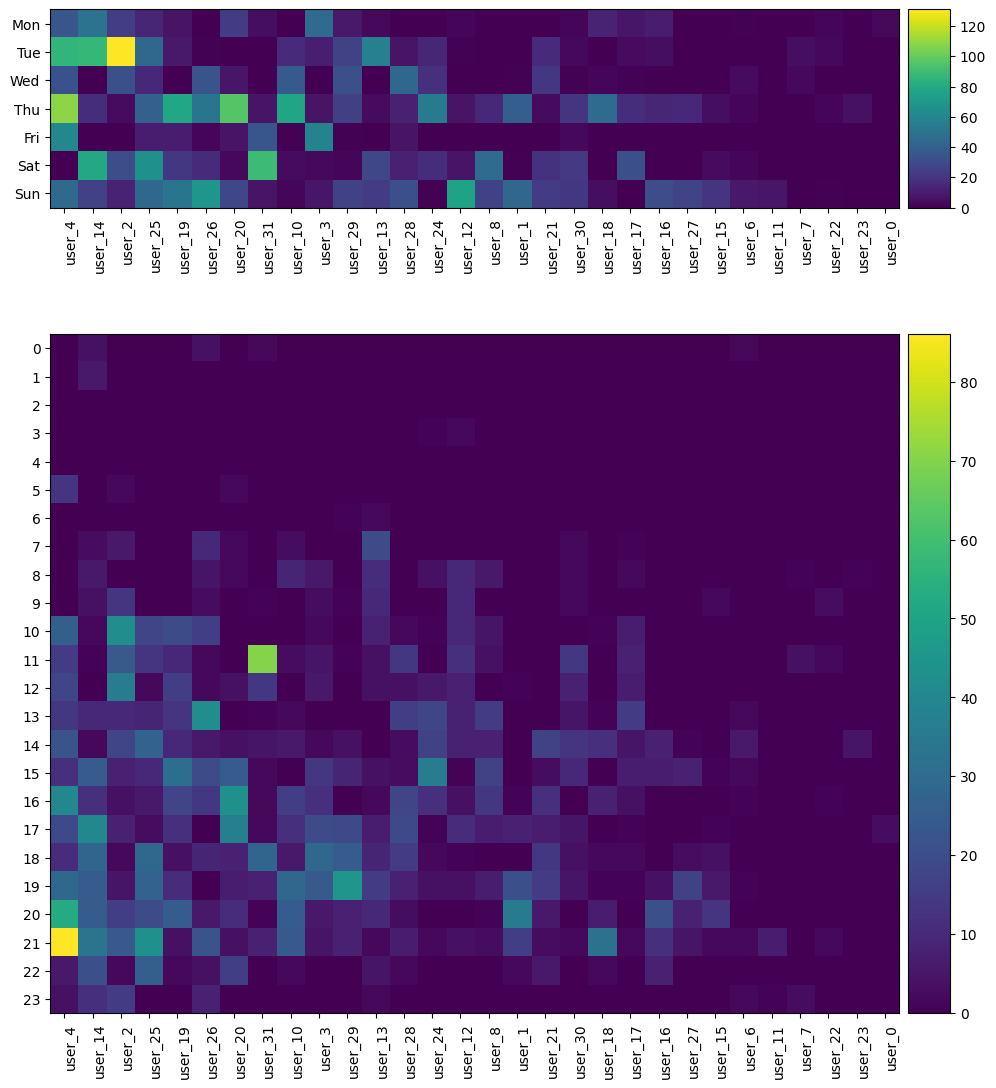

In [3]:
# plt.style.use('ggplot')
# loading of style takes some time
fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(15, 25))

ax1.set_xticks(range(len(users)), labels=users, rotation=90, ha="right", rotation_mode="anchor")
ax1.set_yticks(range(len(days)), labels=days)
im = ax1.imshow(commits1)
ax_divider = make_axes_locatable(ax1)
cax1 = ax_divider.append_axes("right", size="5%", pad="1%")
cb1 = fig.colorbar(im, cax=cax1)

ax2.set_xticks(range(len(users)), labels=users, rotation=90, ha="right", rotation_mode="anchor")
ax2.set_yticks(range(len(hours)), labels=hours)
im1 = ax2.imshow(commits2)
ax_divider = make_axes_locatable(ax2)
cax2 = ax_divider.append_axes("right", size="5%", pad="1%")
cb2 = fig.colorbar(im1, cax=cax2)

plt.tight_layout()
plt.subplots_adjust(left=0.3, right=0.9, top=0.8, bottom=0.3)  
plt.show()

In [4]:
connection.close()

1. Q: Which user has the most commits on Tue?  
A: user_2.
   
3. Q: Which user has the most commits on Thu?  
A: The answer: user_4.

3. On which weekday do the users not like making a lot of commits?  
A: Fri.

5. Which user at which hour made the largest number of commits?  
A: user_4, 21